# 🔍 Notebook 04: Explainability (XAI) Analysis

**Objective:** Apply all 4 XAI methods and produce clinical interpretation reports.

**Methods:**
| Method | Branch | Answers |
|--------|--------|---------|
| **Grad-CAM** | Image | Which scan region drove prediction? |
| **SHAP** | Text | Which clinical words matter most? |
| **LIME** | Image | Superpixel importance map |
| **Integrated Gradients** | Both | Image vs Text contribution (%) |

**Sections:**
1. Load model + test samples
2. Grad-CAM analysis (5 test samples)
3. SHAP analysis (text branch)
4. LIME image analysis
5. Integrated Gradients (modality attribution)
6. XAI Summary Table (all methods combined)
7. XAI quality metrics (faithfulness, consistency)

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from pathlib import Path
from transformers import AutoTokenizer
import torchvision.transforms as T

import config
from src.training.multimodal_predictor import MultimodalClinicalPredictor, MultimodalDataset
from src.explainability.xai_engine import (
    GradCAMEngine, SHAPEngine, LIMEEngine,
    IntegratedGradientsEngine, build_xai_summary_table
)

plt.rcParams['figure.dpi'] = 120
torch.manual_seed(config.RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## 1️⃣ Load Model + Test Samples

In [2]:
# Load best model checkpoint
hf_token  = config.HF_TOKEN if config.HF_TOKEN != 'YOUR_HF_TOKEN_HERE' else None
tokenizer = AutoTokenizer.from_pretrained(config.TEXT_ENCODER_MODEL, token=hf_token)

model = MultimodalClinicalPredictor(
    num_classes=config.NUM_CLASSES,
    text_model_name=config.TEXT_ENCODER_MODEL,
    hidden_dim=config.FUSION_HIDDEN_DIM,
    dropout_rate=0.0,  # Set dropout=0 for deterministic XAI
).to(DEVICE)

if config.BEST_MODEL_PATH.exists():
    model.load_state_dict(torch.load(config.BEST_MODEL_PATH, map_location=DEVICE))
    print('✅ Loaded trained checkpoint:', config.BEST_MODEL_PATH)
else:
    print('⚠️  No checkpoint found — using pretrained weights (untrained fusion) for XAI demonstration')

model.eval()

# Load 5 test samples (one per diverse class if possible)
df_test = pd.read_csv('../data/processed/test.csv')
# Select one sample per class (first 5 unique classes found in test set)
XAI_SAMPLES = []
seen_classes = set()
for _, row in df_test.iterrows():
    if row['label'] not in seen_classes:
        XAI_SAMPLES.append(row)
        seen_classes.add(row['label'])
    if len(XAI_SAMPLES) >= 5:
        break

print(f'\nXAI analysis on {len(XAI_SAMPLES)} test samples:')
for s in XAI_SAMPLES:
    print(f'  {s["image_id"]} | True: {s["label_name"]} | Modality: {s["modality"]}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Loaded trained checkpoint: Z:\study files\SRM_study\SEM-2\AML-509_Agentic AI and GAN\Team Project\Agent_code_Trial-2\Trial_2\models\best_multimodal_model.pt

XAI analysis on 5 test samples:
  MPX2580_synpic39490 | True: Neoplasm | Modality: MR
  MPX1909_synpic16186 | True: Trauma | Modality: MR
  MPX1375_synpic41148 | True: Infection | Modality: CT
  MPX1087_synpic34302 | True: Congenital | Modality: CT
  MPX2518_synpic39513 | True: Clinical Sign/Other | Modality: MR


## 2️⃣ Grad-CAM Analysis

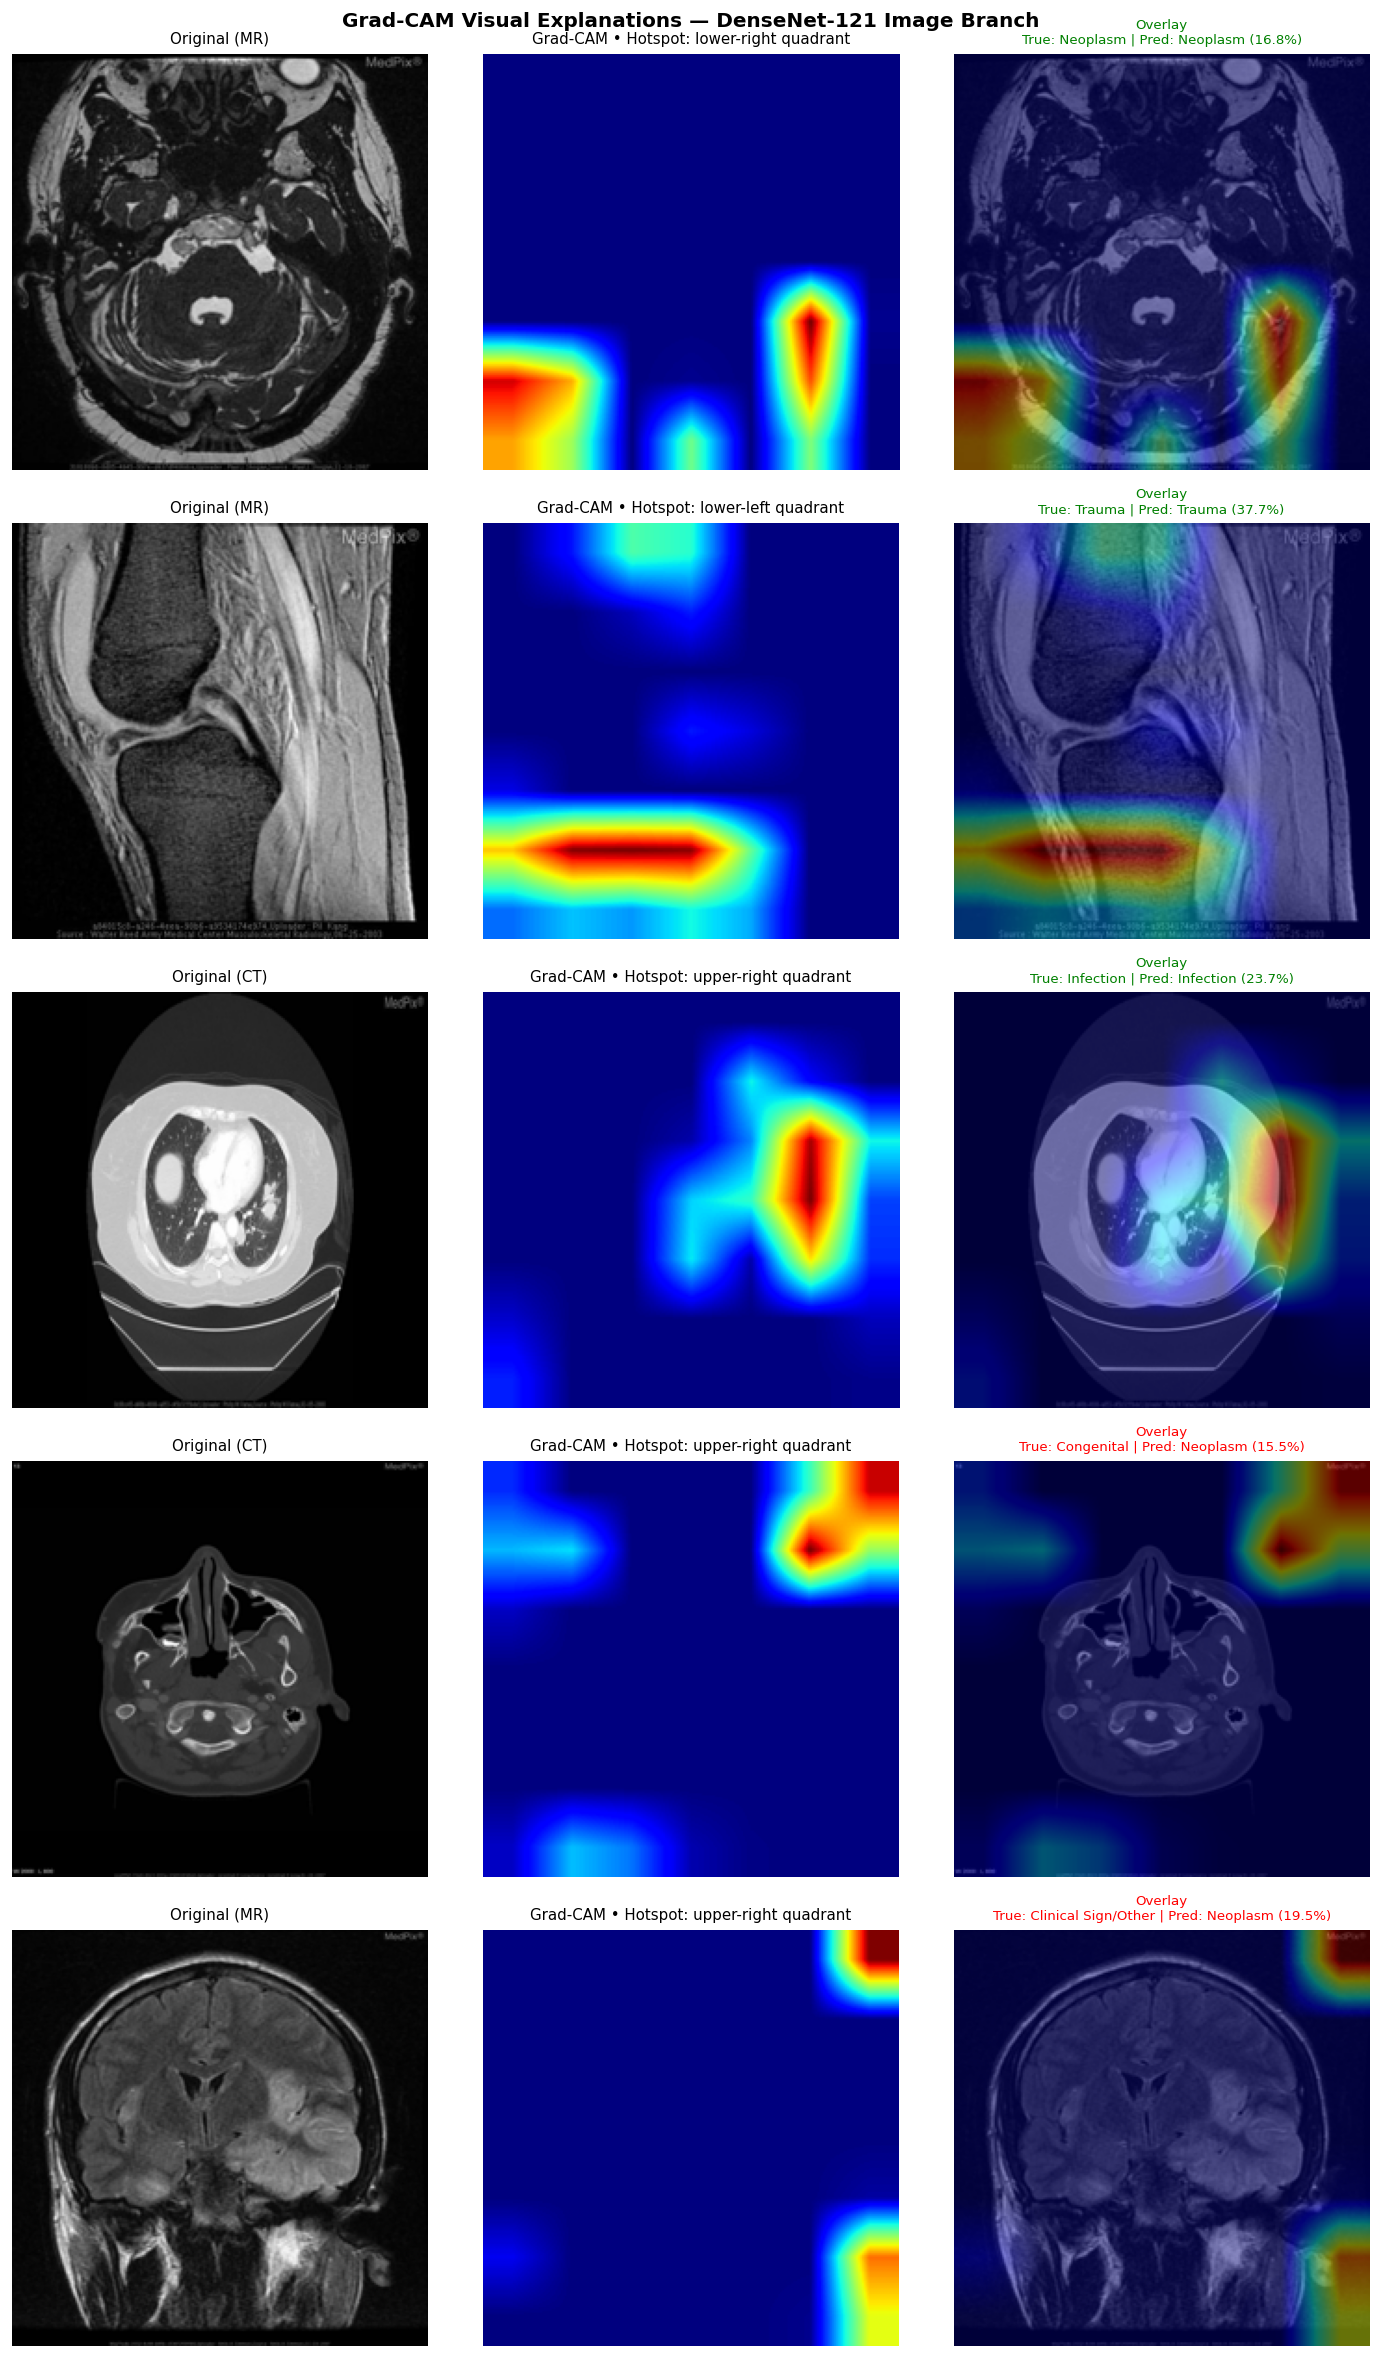

Grad-CAM figure saved.


In [3]:
val_transform = T.Compose([
    T.Resize(config.IMAGE_SIZE), T.ToTensor(),
    T.Normalize(mean=config.IMG_MEAN, std=config.IMG_STD),
])

gradcam_engine = GradCAMEngine(model, target_layer_name=config.GRADCAM_TARGET_LAYER)

fig, axes = plt.subplots(len(XAI_SAMPLES), 3, figsize=(12, 4 * len(XAI_SAMPLES)))
if len(XAI_SAMPLES) == 1:
    axes = [axes]

gradcam_descriptions = []

for row_idx, sample in enumerate(XAI_SAMPLES):
    # Load and preprocess image
    img_pil   = Image.open(sample['image_path']).convert('RGB').resize(config.IMAGE_SIZE)
    img_np    = np.array(img_pil)  # (H, W, 3) uint8
    img_t     = val_transform(img_pil).unsqueeze(0).to(DEVICE)

    # Tokenize text
    enc = tokenizer(str(sample['text']), max_length=config.MAX_TEXT_LENGTH,
                    padding='max_length', truncation=True, return_tensors='pt')
    ids  = enc['input_ids'].to(DEVICE)
    mask = enc['attention_mask'].to(DEVICE)

    # Generate Grad-CAM
    cam = gradcam_engine.generate_cam(img_t, ids, mask)
    overlay = gradcam_engine.overlay_cam_on_image(img_np, cam[0], alpha=0.45)

    # Get prediction
    with torch.no_grad():
        logits = model(img_t, ids, mask)
        pred_idx = logits.argmax(-1).item()
        conf     = F.softmax(logits, -1)[0, pred_idx].item()

    # Find hotspot location
    hot_y, hot_x = np.unravel_index(cam[0].argmax(), cam[0].shape)
    h_label = 'upper' if hot_y < config.IMAGE_SIZE[0] // 2 else 'lower'
    w_label = 'left'  if hot_x < config.IMAGE_SIZE[1] // 2 else 'right'
    desc = f'{h_label}-{w_label} quadrant'
    gradcam_descriptions.append(desc)

    axes[row_idx][0].imshow(img_np)
    axes[row_idx][0].set_title(f'Original ({sample["modality"]})', fontsize=9)
    axes[row_idx][0].axis('off')

    im = axes[row_idx][1].imshow(cam[0], cmap='jet', vmin=0, vmax=1)
    axes[row_idx][1].set_title(f'Grad-CAM • Hotspot: {desc}', fontsize=9)
    axes[row_idx][1].axis('off')

    axes[row_idx][2].imshow(overlay)
    axes[row_idx][2].set_title(
        f'Overlay\nTrue: {sample["label_name"]} | Pred: {config.CLASS_NAMES[pred_idx]} ({conf:.1%})',
        fontsize=8, color='green' if pred_idx == sample['label'] else 'red'
    )
    axes[row_idx][2].axis('off')

plt.suptitle('Grad-CAM Visual Explanations — DenseNet-121 Image Branch', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/gradcam/gradcam_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print('Grad-CAM figure saved.')

## 3️⃣ SHAP Text Analysis

In [4]:
import shap

shap_engine = SHAPEngine(model, tokenizer, device=DEVICE, max_length=config.MAX_TEXT_LENGTH)

# Run SHAP on the text field of our XAI samples
sample_texts = [str(s['text']) for s in XAI_SAMPLES]

print('Computing SHAP values... (this may take 1-3 minutes per sample)')
shap_values = shap_engine.explain(sample_texts, max_evals=config.NUM_SHAP_SAMPLES)

all_top_tokens = []
print('\n=== TOP SHAP TOKENS PER SAMPLE ===')
for i, sample in enumerate(XAI_SAMPLES):
    # Get predicted label index
    enc = tokenizer(str(sample['text']), max_length=config.MAX_TEXT_LENGTH,
                    padding='max_length', truncation=True, return_tensors='pt')
    with torch.no_grad():
        dummy_img = torch.zeros(1, 3, 224, 224, device=DEVICE)
        logits = model(dummy_img, enc['input_ids'].to(DEVICE), enc['attention_mask'].to(DEVICE))
        pred_idx = logits.argmax(-1).item()

    top_tokens = shap_engine.get_top_tokens(shap_values, i, pred_idx, top_k=10)
    all_top_tokens.append(top_tokens)

    print(f'\nSample {i+1}: {sample["image_id"]} (True: {sample["label_name"]})')
    for t in top_tokens:
        bar_len = int(abs(t['shap_score']) * 200)
        direction = '▶' if t['shap_score'] > 0 else '◀'
        print(f'  {direction} "{t["token"]:25s}" : {t["shap_score"]:+.4f}')

Computing SHAP values... (this may take 1-3 minutes per sample)


PartitionExplainer explainer: 6it [00:21,  4.22s/it]                       



=== TOP SHAP TOKENS PER SAMPLE ===

Sample 1: MPX2580_synpic39490 (True: Neoplasm)
  ◀ "A                        " : -0.0001
  ◀ "xial                     " : -0.0001
  ◀ "T                        " : -0.0001
  ◀ "1                        " : -0.0001
  ◀ "weighted                 " : -0.0001
  ◀ "images                   " : -0.0001
  ◀ "demonstrates             " : -0.0001
  ◀ "the                      " : -0.0001
  ◀ "pre                      " : -0.0001
  ◀ "pont                     " : -0.0001

Sample 2: MPX1909_synpic16186 (True: Trauma)
  ▶ "M                        " : +0.0009
  ▶ "R                        " : +0.0009
  ▶ "sequence                 " : +0.0009
  ▶ "images                   " : +0.0009
  ▶ "male                     " : +0.0009
  ▶ "in                       " : +0.0009
  ▶ "ju                       " : +0.0009
  ▶ "ried                     " : +0.0009
  ▶ "sa                       " : +0.0009
  ▶ "git                      " : +0.0009

Sample 3: MPX1375_synpic41148

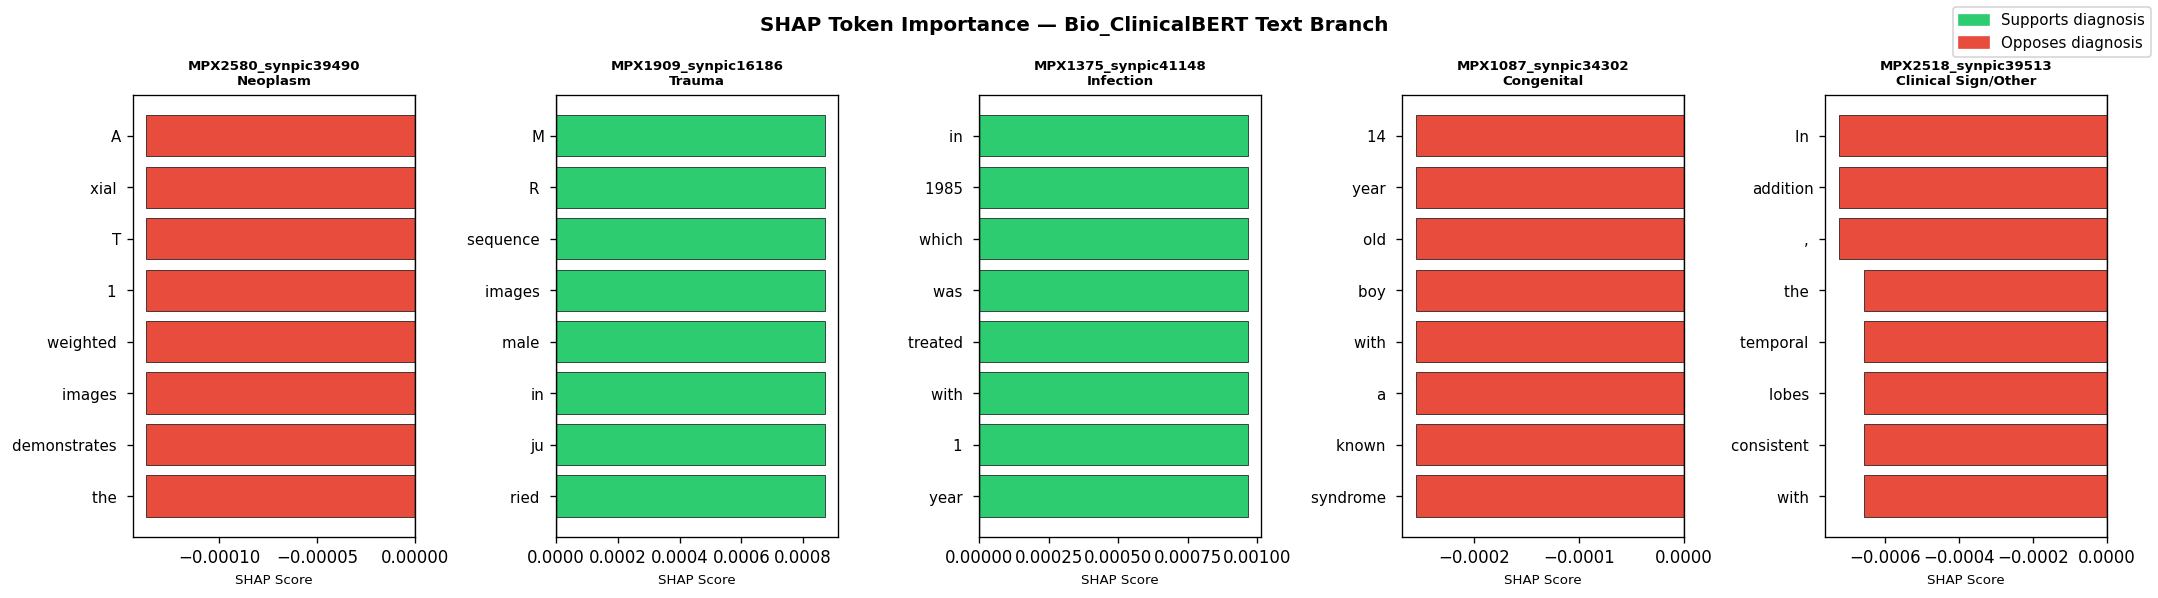

In [5]:
# Visualize SHAP bar charts for each sample
fig, axes = plt.subplots(1, len(XAI_SAMPLES), figsize=(18, 5))
if len(XAI_SAMPLES) == 1:
    axes = [axes]

for i, (sample, top_tokens) in enumerate(zip(XAI_SAMPLES, all_top_tokens)):
    tokens = [t['token'] for t in top_tokens[:8]]
    scores = [t['shap_score'] for t in top_tokens[:8]]
    colors = ['#2ecc71' if s > 0 else '#e74c3c' for s in scores]

    axes[i].barh(range(len(tokens)), scores, color=colors, edgecolor='black', linewidth=0.4)
    axes[i].set_yticks(range(len(tokens)))
    axes[i].set_yticklabels(tokens, fontsize=9)
    axes[i].axvline(0, color='black', linewidth=0.8)
    axes[i].set_title(f'{sample["image_id"]}\n{sample["label_name"]}', fontsize=8, fontweight='bold')
    axes[i].set_xlabel('SHAP Score', fontsize=8)
    axes[i].invert_yaxis()  # Most important on top

# Legend
legend_patches = [
    mpatches.Patch(color='#2ecc71', label='Supports diagnosis'),
    mpatches.Patch(color='#e74c3c', label='Opposes diagnosis'),
]
fig.legend(handles=legend_patches, loc='upper right', fontsize=9)
plt.suptitle('SHAP Token Importance — Bio_ClinicalBERT Text Branch', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/shap/shap_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

## 4️⃣ Integrated Gradients — Modality Contribution

=== INTEGRATED GRADIENTS — MODALITY ATTRIBUTION ===
  MPX2580_synpic39490            | Image: 62.8% | Text: 37.2% | Dominant: IMAGE
  MPX1909_synpic16186            | Image: 68.0% | Text: 32.0% | Dominant: IMAGE
  MPX1375_synpic41148            | Image: 67.3% | Text: 32.7% | Dominant: IMAGE
  MPX1087_synpic34302            | Image: 63.0% | Text: 37.0% | Dominant: IMAGE
  MPX2518_synpic39513            | Image: 63.8% | Text: 36.2% | Dominant: IMAGE


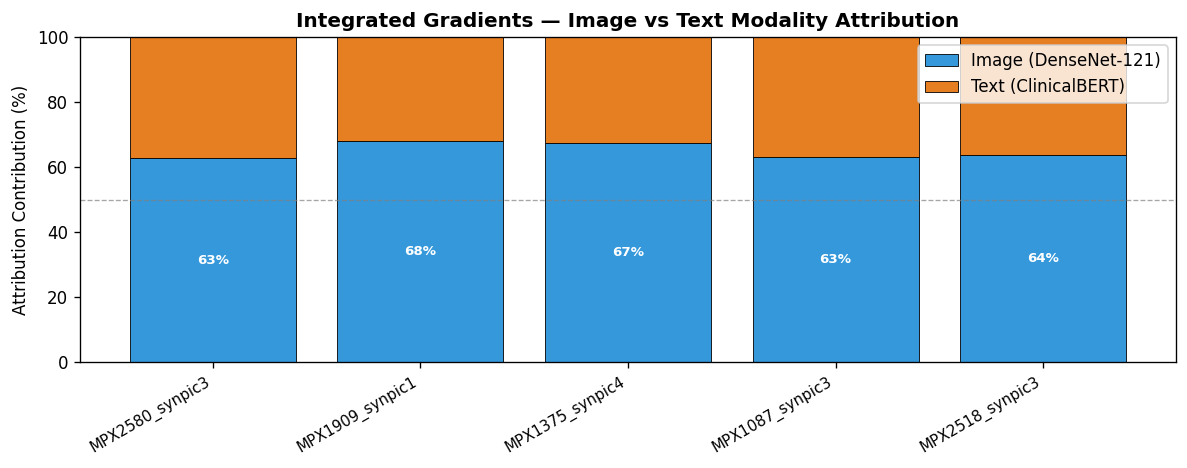

In [6]:
ig_engine = IntegratedGradientsEngine(model)

ig_results_list = []
dominant_modalities = []

print('=== INTEGRATED GRADIENTS — MODALITY ATTRIBUTION ===')
for sample in XAI_SAMPLES:
    img_pil = Image.open(sample['image_path']).convert('RGB')
    img_t   = val_transform(img_pil).unsqueeze(0).to(DEVICE)
    enc  = tokenizer(str(sample['text']), max_length=config.MAX_TEXT_LENGTH,
                     padding='max_length', truncation=True, return_tensors='pt')
    ids  = enc['input_ids'].to(DEVICE)
    mask = enc['attention_mask'].to(DEVICE)

    ig_res = ig_engine.compute_attributions(img_t, ids, mask, n_steps=config.NUM_IG_STEPS)
    ig_results_list.append(ig_res)
    dominant_modalities.append(ig_res['dominant_modality'][0])

    img_pct  = ig_res['image_contribution_pct'][0]
    txt_pct  = ig_res['text_contribution_pct'][0]
    dominant = ig_res['dominant_modality'][0]

    print(f'  {sample["image_id"]:30s} | Image: {img_pct:.1f}% | Text: {txt_pct:.1f}% | Dominant: {dominant.upper()}')

# Visualization: stacked bar chart of modality contributions
img_pcts = [r['image_contribution_pct'][0] for r in ig_results_list]
txt_pcts = [r['text_contribution_pct'][0]  for r in ig_results_list]
sample_ids_short = [s['image_id'][:15] for s in XAI_SAMPLES]

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(sample_ids_short))
bars1 = ax.bar(x, img_pcts, color='#3498DB', label='Image (DenseNet-121)', edgecolor='black', lw=0.5)
bars2 = ax.bar(x, txt_pcts, bottom=img_pcts, color='#E67E22', label='Text (ClinicalBERT)', edgecolor='black', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(sample_ids_short, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Attribution Contribution (%)')
ax.set_title('Integrated Gradients — Image vs Text Modality Attribution', fontweight='bold')
ax.legend(); ax.set_ylim(0, 100)
ax.axhline(50, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)

for bar, pct in zip(bars1, img_pcts):
    ax.text(bar.get_x() + bar.get_width()/2, pct/2, f'{pct:.0f}%', ha='center', va='center', fontsize=8, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/ig_modality_attribution.png', bbox_inches='tight', dpi=150)
plt.show()

## 5️⃣ XAI Summary Table

In [7]:
# Get predictions and confidences for all XAI samples
pred_labels_list = []
confidence_list  = []

for sample in XAI_SAMPLES:
    img_pil = Image.open(sample['image_path']).convert('RGB')
    img_t   = val_transform(img_pil).unsqueeze(0).to(DEVICE)
    enc = tokenizer(str(sample['text']), max_length=config.MAX_TEXT_LENGTH,
                    padding='max_length', truncation=True, return_tensors='pt')
    ids  = enc['input_ids'].to(DEVICE)
    mask = enc['attention_mask'].to(DEVICE)

    pred_idx, probs = model.predict(img_t, ids, mask)
    pred_labels_list.append(config.CLASS_NAMES[pred_idx[0].item()])
    confidence_list.append(probs[0, pred_idx[0].item()].item())

# Build XAI summary table
xai_table = build_xai_summary_table(
    sample_ids       = [s['image_id'] for s in XAI_SAMPLES],
    true_labels      = [s['label_name'] for s in XAI_SAMPLES],
    pred_labels      = pred_labels_list,
    confidences      = confidence_list,
    top_shap_tokens  = all_top_tokens,
    gradcam_summaries= gradcam_descriptions,
    dominant_modalities = dominant_modalities,
)

print('=== XAI SUMMARY TABLE ===')
pd.set_option('display.max_colwidth', 60)
display(xai_table)

xai_table.to_csv('../outputs/xai_summary_table.csv', index=False)
print('\nXAI Summary Table saved to: outputs/xai_summary_table.csv')

=== XAI SUMMARY TABLE ===


,Sample_ID,True_Label,Predicted_Label,Confidence,Top_SHAP_Tokens,GradCAM_Region,Dominant_Modality
0,MPX2580_synpic39490,Neoplasm,Neoplasm,16.87%,"A (-0.000), xial (-0.000), T (-0.000), 1 (-0.000), wei...",lower-right quadrant,image
1,MPX1909_synpic16186,Trauma,Trauma,38.09%,"M (+0.001), R (+0.001), sequence (+0.001), images (+0...",lower-left quadrant,image
2,MPX1375_synpic41148,Infection,Infection,23.28%,"in (+0.001), 1985 (+0.001), which (+0.001), was (+0....",upper-right quadrant,image
3,MPX1087_synpic34302,Congenital,Neoplasm,15.05%,"14 (-0.000), year (-0.000), old (-0.000), boy (-0.00...",upper-right quadrant,image
4,MPX2518_synpic39513,Clinical Sign/Other,Neoplasm,19.21%,"In (-0.001), addition (-0.001), , (-0.001), the (-0.0...",upper-right quadrant,image



XAI Summary Table saved to: outputs/xai_summary_table.csv


## 6️⃣ XAI Faithfulness Metric

In [8]:
# Faithfulness test: mask top SHAP tokens and measure prediction drop
# A faithful explanation should cause a significant drop when top features are removed

print('=== FAITHFULNESS ANALYSIS (SHAP Text Masking) ===')
faithfulness_scores = []

for i, sample in enumerate(XAI_SAMPLES):
    original_text = str(sample['text'])
    top_tokens_to_mask = [t['token'] for t in all_top_tokens[i][:5]]  # Top 5 tokens

    # Create masked version (replace top tokens with [MASK])
    masked_text = original_text
    for token in top_tokens_to_mask:
        masked_text = masked_text.replace(token, '[MASK]')

    # Get original confidence
    img_pil = Image.open(sample['image_path']).convert('RGB')
    img_t   = val_transform(img_pil).unsqueeze(0).to(DEVICE)

    def get_confidence(text):
        enc = tokenizer(text, max_length=config.MAX_TEXT_LENGTH,
                        padding='max_length', truncation=True, return_tensors='pt')
        with torch.no_grad():
            logits = model(img_t, enc['input_ids'].to(DEVICE), enc['attention_mask'].to(DEVICE))
            probs  = F.softmax(logits, -1)[0]
            return probs[sample['label']].item()

    orig_conf   = get_confidence(original_text)
    masked_conf = get_confidence(masked_text)
    drop = orig_conf - masked_conf
    faithfulness_scores.append(drop)

    print(f'  {sample["image_id"]:30s} | Original conf: {orig_conf:.3f} | Masked conf: {masked_conf:.3f} | Drop: {drop:+.3f}')

avg_faithfulness = np.mean(faithfulness_scores)
print(f'\nAverage Faithfulness Score: {avg_faithfulness:.4f}')
print(f'(Positive value = SHAP explanations are faithful — masking key tokens reduces confidence)')
print('\n✅ Explainability analysis complete. Proceed to Notebook 05: RAG Retrieval.')

=== FAITHFULNESS ANALYSIS (SHAP Text Masking) ===
  MPX2580_synpic39490            | Original conf: 0.169 | Masked conf: 0.130 | Drop: +0.038
  MPX1909_synpic16186            | Original conf: 0.381 | Masked conf: 0.357 | Drop: +0.024
  MPX1375_synpic41148            | Original conf: 0.233 | Masked conf: 0.233 | Drop: -0.000
  MPX1087_synpic34302            | Original conf: 0.124 | Masked conf: 0.116 | Drop: +0.008
  MPX2518_synpic39513            | Original conf: 0.083 | Masked conf: 0.084 | Drop: -0.001

Average Faithfulness Score: 0.0138
(Positive value = SHAP explanations are faithful — masking key tokens reduces confidence)

✅ Explainability analysis complete. Proceed to Notebook 05: RAG Retrieval.
